# Compulsory Assignment #2
## Machine Learning and Deep Learning (CDSCO2041C)

**Group Members Student IDs:**

- Giorgio Imbò 185930
- Valerio Gatti 186647
- Giada Salvato 186612

## Overview

This notebook addresses three research questions regarding the allocation of DKK 250,000 between Ethereum (ETH/DKK) and Novo Nordisk (XCSE) stock:

1. **Asset Selection** – Should we invest in Ethereum or Novo Nordisk?
2. **Capital Allocation Strategy** – Pure vs. hybrid strategy and investment horizon?
3. **Market Timing and Seasonality** – Are there seasonal patterns or favorable entry points?

**Methodology at a Glance:**
- Exploratory data analysis & return statistics
- Market regime detection (HMM)
- Anomaly detection (Z-score, IQR, Isolation Forest)
- Crash regime probability estimation
- Supervised learning: return direction prediction (Logistic Regression, Random Forest, Gradient Boosting)
- Regularization & feature selection (LASSO/Ridge, feature importances)
- Interpretable decision rules (Decision Tree)
- Seasonality analysis
- Portfolio optimization (mean-variance)


## 0. Imports & Setup

In [4]:
#!pip install statsmodels
#!pip install scikit-learn
#!pip install hmmlearn

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV, Lasso, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

from hmmlearn.hmm import GaussianHMM

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (14, 5)

SEED = 42
np.random.seed(SEED)
print('All libraries loaded successfully.')

All libraries loaded successfully.


## 1. Data Loading & Preprocessing

In [5]:
# ── Load Novo Nordisk (XCSE) ──────────────────────────────────────────────────
novo_raw = pd.read_csv('_XCSE_NOVO-1.csv')
novo_raw.columns = ['Date','Open','High','Low','Close','Volume']

# Prices are formatted as '.238.00' (Danish leading dot + decimal price)
# Strip leading dot to get standard float string
for col in ['Open','High','Low','Close']:
    novo_raw[col] = (
        novo_raw[col].astype(str)
        .str.replace('"','', regex=False).str.strip().str.lstrip('.')
        .pipe(lambda s: pd.to_numeric(s, errors='coerce'))
    )
novo_raw['Volume'] = (
    novo_raw['Volume'].astype(str)
    .str.replace('"','', regex=False).str.replace(',','', regex=False)
    .pipe(lambda s: pd.to_numeric(s, errors='coerce'))
)
novo_raw['Date'] = pd.to_datetime(novo_raw['Date'], format='%m/%d/%Y')
novo = novo_raw.sort_values('Date').set_index('Date').dropna()

# ── Load Ethereum (ETH/DKK) ───────────────────────────────────────────────────
eth_raw = pd.read_csv('_eth_dkk.csv', sep=';')
eth_raw.columns = ['Date','Open','High','Low','Close','Volume','MarketCap','Change_pct']
eth_raw['Date'] = pd.to_datetime(eth_raw['Date'])
# Volume is formatted as '132.89B', '111.54M', etc.
def _parse_vol(s):
    s = str(s).strip()
    if s.endswith('B'): return float(s[:-1]) * 1e9
    if s.endswith('M'): return float(s[:-1]) * 1e6
    if s.endswith('K'): return float(s[:-1]) * 1e3
    try: return float(s)
    except: return np.nan
eth_raw['Volume'] = eth_raw['Volume'].apply(_parse_vol)
eth = eth_raw.sort_values('Date').set_index('Date')[['Open','High','Low','Close','Volume']].dropna()

print(f'Novo Nordisk: {novo.shape[0]} rows | {novo.index.min().date()} → {novo.index.max().date()}')
print(f'Ethereum:     {eth.shape[0]} rows | {eth.index.min().date()} → {eth.index.max().date()}')
print(f'Novo Close range: {novo.Close.min():.2f} – {novo.Close.max():.2f} DKK')
print(f'ETH  Close range: {eth.Close.min():.2f} – {eth.Close.max():.2f} DKK')
display(novo.head(3))
display(eth.head(3))

Novo Nordisk: 250 rows | 2025-02-27 → 2026-02-27
Ethereum:     366 rows | 2025-03-01 → 2026-03-01
Novo Close range: 237.90 – 644.50 DKK
ETH  Close range: 10040.85 – 30768.21 DKK


,Open,High,Low,Close,Volume
Date,,,,,
2025-02-27,630.0,645.8,628.3,641.8,2974061
2025-02-28,641.0,648.2,631.2,644.5,7285161
2025-03-03,650.0,651.2,636.2,639.1,2242871


,Open,High,Low,Close,Volume
Date,,,,,
2025-03-01,16081.11,16394.10,15399.37,15935.94,1.328900e+11
2025-03-02,15936.01,18330.51,15610.02,18097.15,1.115400e+11
2025-03-03,17932.04,17970.78,14939.64,15303.53,2.945900e+11


In [6]:
# ── Compute Daily Log-Returns ─────────────────────────────────────────────────
novo['ret'] = np.log(novo['Close'] / novo['Close'].shift(1))
eth['ret']  = np.log(eth['Close']  / eth['Close'].shift(1))

novo.dropna(inplace=True)
eth.dropna(inplace=True)

print('Return series computed.')
print(f'  Novo: {len(novo)} obs | ETH: {len(eth)} obs')

Return series computed.
  Novo: 249 obs | ETH: 365 obs


## 2. Exploratory Data Analysis

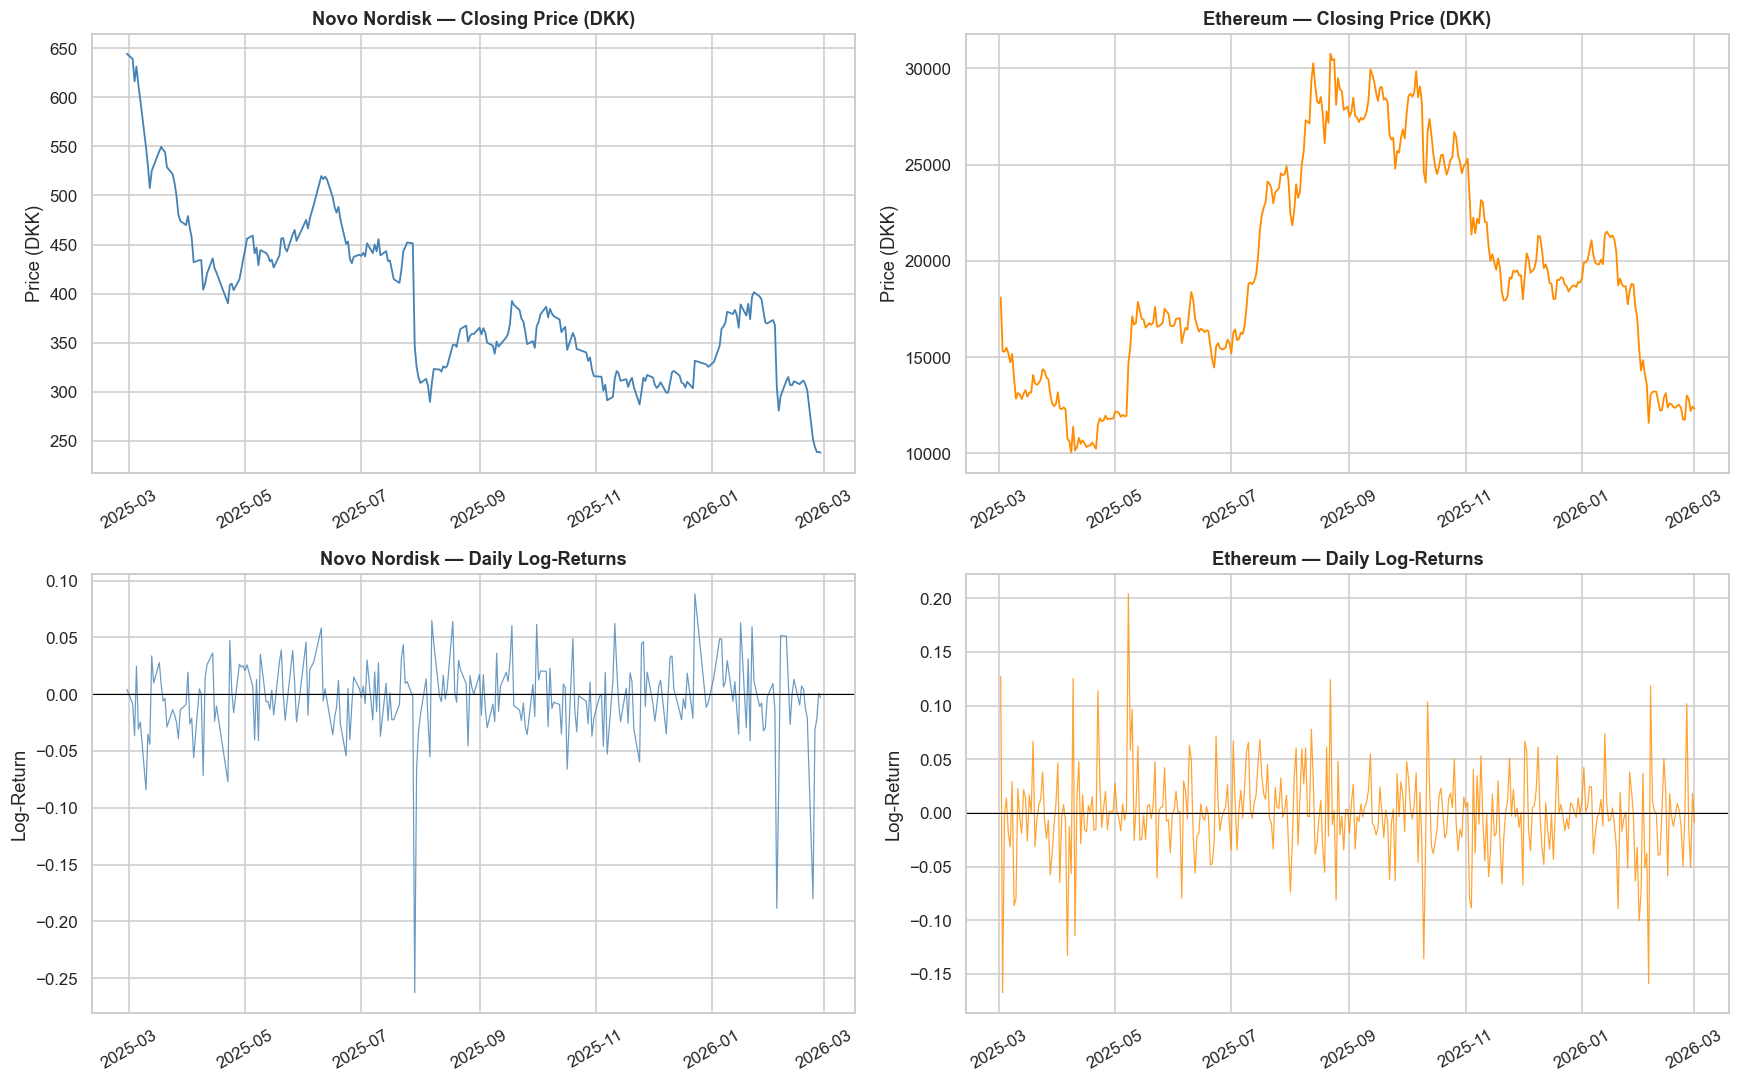

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(novo.index, novo['Close'], color='steelblue', lw=1.2)
axes[0,0].set_title('Novo Nordisk — Closing Price (DKK)', fontweight='bold')
axes[0,0].set_ylabel('Price (DKK)')

axes[0,1].plot(eth.index, eth['Close'], color='darkorange', lw=1.2)
axes[0,1].set_title('Ethereum — Closing Price (DKK)', fontweight='bold')
axes[0,1].set_ylabel('Price (DKK)')

axes[1,0].plot(novo.index, novo['ret'], color='steelblue', lw=0.8, alpha=0.8)
axes[1,0].set_title('Novo Nordisk — Daily Log-Returns', fontweight='bold')
axes[1,0].set_ylabel('Log-Return')
axes[1,0].axhline(0, color='black', lw=0.7)

axes[1,1].plot(eth.index, eth['ret'], color='darkorange', lw=0.8, alpha=0.8)
axes[1,1].set_title('Ethereum — Daily Log-Returns', fontweight='bold')
axes[1,1].set_ylabel('Log-Return')
axes[1,1].axhline(0, color='black', lw=0.7)

for ax in axes.flat:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

In [8]:
# ── Descriptive Statistics ────────────────────────────────────────────────────
def describe_returns(series, name, trading_days=252):
    s = series.dropna()
    ann_ret = s.mean() * trading_days
    ann_vol = s.std() * np.sqrt(trading_days)
    sharpe  = ann_ret / ann_vol if ann_vol != 0 else np.nan
    skew    = s.skew()
    kurt    = s.kurtosis()
    max_dd  = (np.exp(s.cumsum()) / np.exp(s.cumsum()).cummax() - 1).min()
    var95   = np.percentile(s, 5)
    return pd.Series({
        'Ann. Return': f'{ann_ret:.2%}',
        'Ann. Volatility': f'{ann_vol:.2%}',
        'Sharpe Ratio': f'{sharpe:.3f}',
        'Skewness': f'{skew:.3f}',
        'Excess Kurtosis': f'{kurt:.3f}',
        'Max Drawdown': f'{max_dd:.2%}',
        'VaR 95% (daily)': f'{var95:.2%}',
    }, name=name)

stats_df = pd.concat([
    describe_returns(novo['ret'], 'Novo Nordisk'),
    describe_returns(eth['ret'],  'Ethereum')
], axis=1)
display(stats_df)

,Novo Nordisk,Ethereum
Ann. Return,-100.44%,-17.77%
Ann. Volatility,58.54%,64.57%
Sharpe Ratio,-1.716,-0.275
Skewness,-2.201,0.122
Excess Kurtosis,12.993,3.795
Max Drawdown,-63.09%,-62.34%
VaR 95% (daily),-5.37%,-6.35%


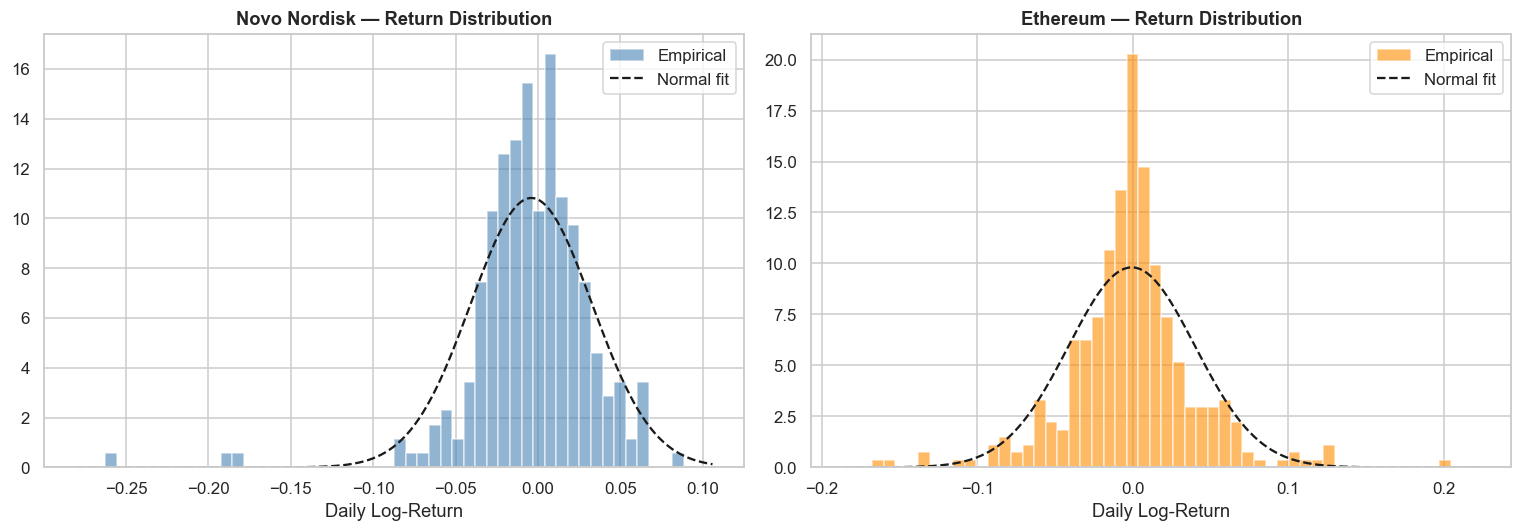

In [ ]:
# ── Return Distribution Comparison ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, name, color) in zip(axes, [
        (novo, 'Novo Nordisk', 'steelblue'),
        (eth,  'Ethereum',     'darkorange')]):
    r = df['ret'].dropna()
    ax.hist(r, bins=50, density=True, color=color, alpha=0.6, label='Empirical')
    xmin, xmax = ax.get_xlim()
    xs = np.linspace(xmin, xmax, 300)
    ax.plot(xs, stats.norm.pdf(xs, r.mean(), r.std()), 'k--', lw=1.5, label='Normal fit')
    ax.set_title(f'{name} — Return Distribution', fontweight='bold')
    ax.set_xlabel('Daily Log-Return')
    ax.legend()

plt.tight_layout()
plt.show()

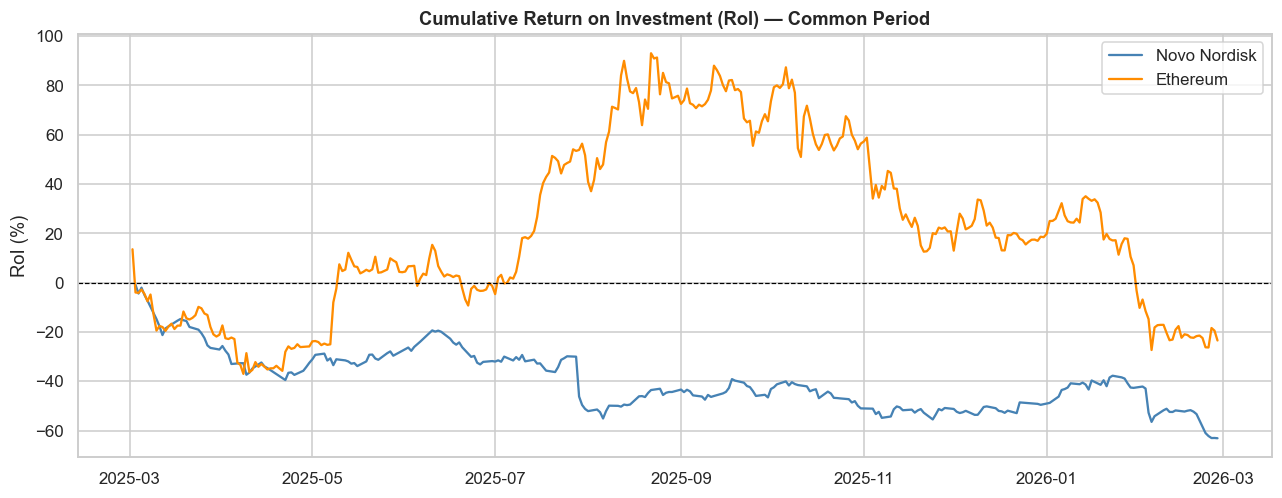


Final RoI on DKK 250,000 (common period: 2025-03-02 → 2026-02-27)
  Novo Nordisk : -63.09%  →  DKK 92,281
  Ethereum     : -23.43%  →  DKK 191,419


In [ ]:
# ── Cumulative Returns & RoI ──────────────────────────────────────────────────
# Find common date range
start = max(novo.index.min(), eth.index.min())
end   = min(novo.index.max(), eth.index.max())

novo_c = novo.loc[start:end, 'ret'].cumsum()
eth_c  = eth.loc[start:end, 'ret'].cumsum()

novo_roi = np.exp(novo_c) - 1
eth_roi  = np.exp(eth_c)  - 1

plt.figure(figsize=(14, 5))
plt.plot(novo_roi.index, novo_roi * 100, label='Novo Nordisk', color='steelblue', lw=1.5)
plt.plot(eth_roi.index,  eth_roi  * 100, label='Ethereum',     color='darkorange', lw=1.5)
plt.axhline(0, color='black', lw=0.8, linestyle='--')
plt.title('Cumulative Return on Investment (RoI) — Common Period', fontweight='bold')
plt.ylabel('RoI (%)')
plt.legend()
plt.show()

print(f'\nFinal RoI on DKK 250,000 (common period: {start.date()} → {end.date()})')
print(f'  Novo Nordisk : {novo_roi.iloc[-1]:.2%}  →  DKK {250_000 * (1 + novo_roi.iloc[-1]):,.0f}')
print(f'  Ethereum     : {eth_roi.iloc[-1]:.2%}  →  DKK {250_000 * (1 + eth_roi.iloc[-1]):,.0f}')

## 3. Market Regime Detection (Hidden Markov Model)

In [11]:
def fit_hmm(returns, n_states=2, name='Asset'):
    """Fit a 2-state Gaussian HMM on returns."""
    X = returns.values.reshape(-1, 1)
    model = GaussianHMM(n_components=n_states, covariance_type='full',
                        n_iter=2000, random_state=SEED)
    model.fit(X)
    states = model.predict(X)

    # Identify which state is high-volatility
    means  = [model.means_[i][0] for i in range(n_states)]
    vols   = [np.sqrt(model.covars_[i][0,0]) for i in range(n_states)]
    hi_vol = int(np.argmax(vols))
    lo_vol = 1 - hi_vol

    print(f'\n── {name} HMM ({n_states} states) ──────────────────────────')
    for i in range(n_states):
        label = 'HIGH-VOL (crash)' if i == hi_vol else 'LOW-VOL  (calm) '
        print(f'  State {i} [{label}]: mean={means[i]:.4f}, vol={vols[i]:.4f}, '
              f'freq={np.mean(states==i):.1%}')

    return model, states, hi_vol

hmm_novo, states_novo, hi_novo = fit_hmm(novo['ret'], name='Novo Nordisk')
hmm_eth,  states_eth,  hi_eth  = fit_hmm(eth['ret'],  name='Ethereum')


── Novo Nordisk HMM (2 states) ──────────────────────────
  State 0 [HIGH-VOL (crash)]: mean=-0.1253, vol=0.1010, freq=1.6%
  State 1 [LOW-VOL  (calm) ]: mean=-0.0009, vol=0.0288, freq=98.4%

── Ethereum HMM (2 states) ──────────────────────────
  State 0 [LOW-VOL  (calm) ]: mean=-0.0004, vol=0.0286, freq=92.6%
  State 1 [HIGH-VOL (crash)]: mean=-0.0024, vol=0.0804, freq=7.4%


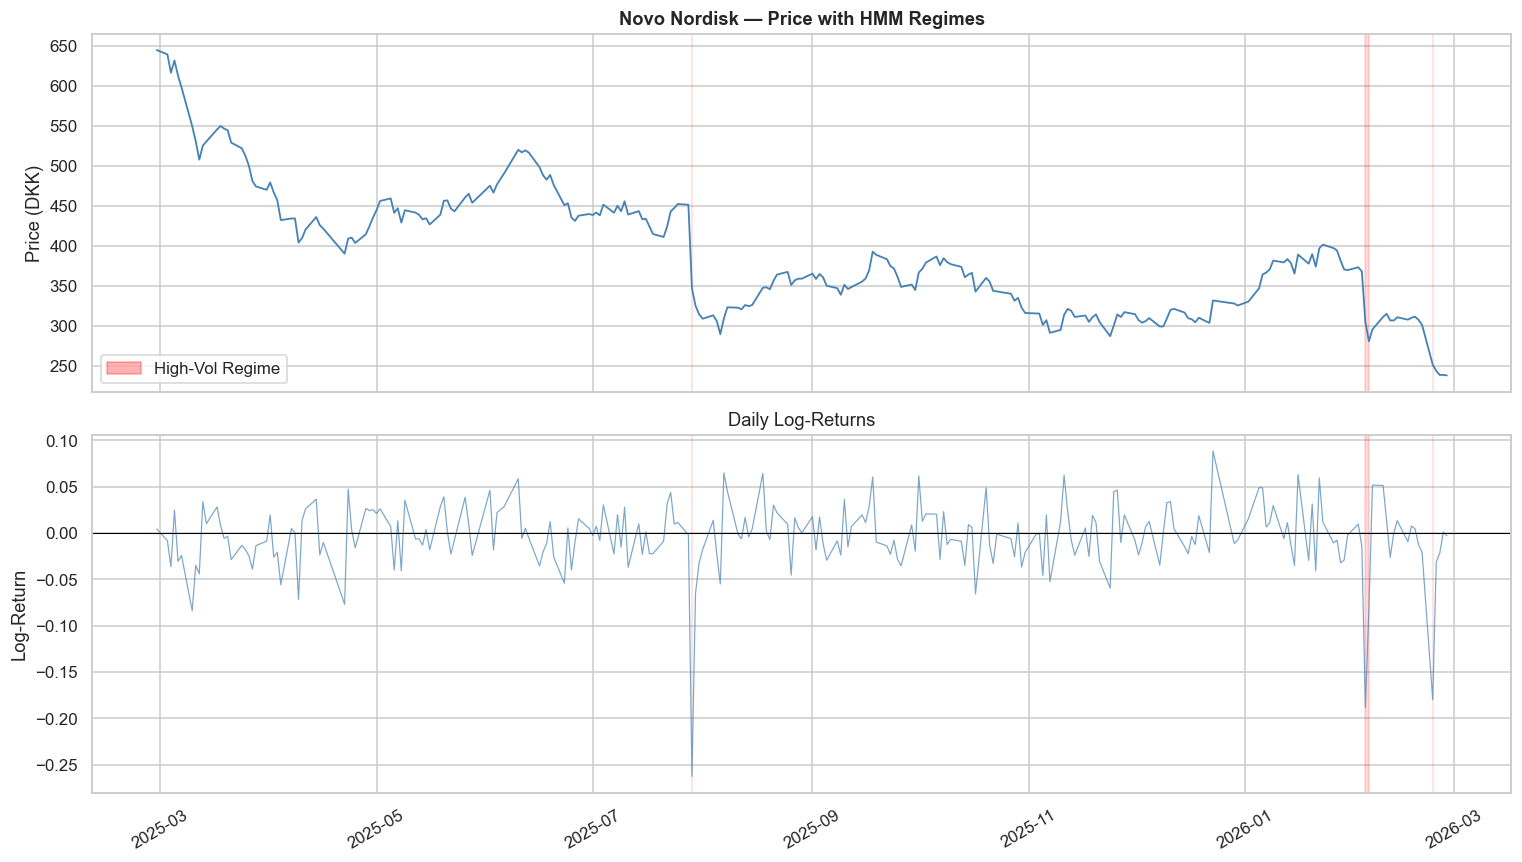

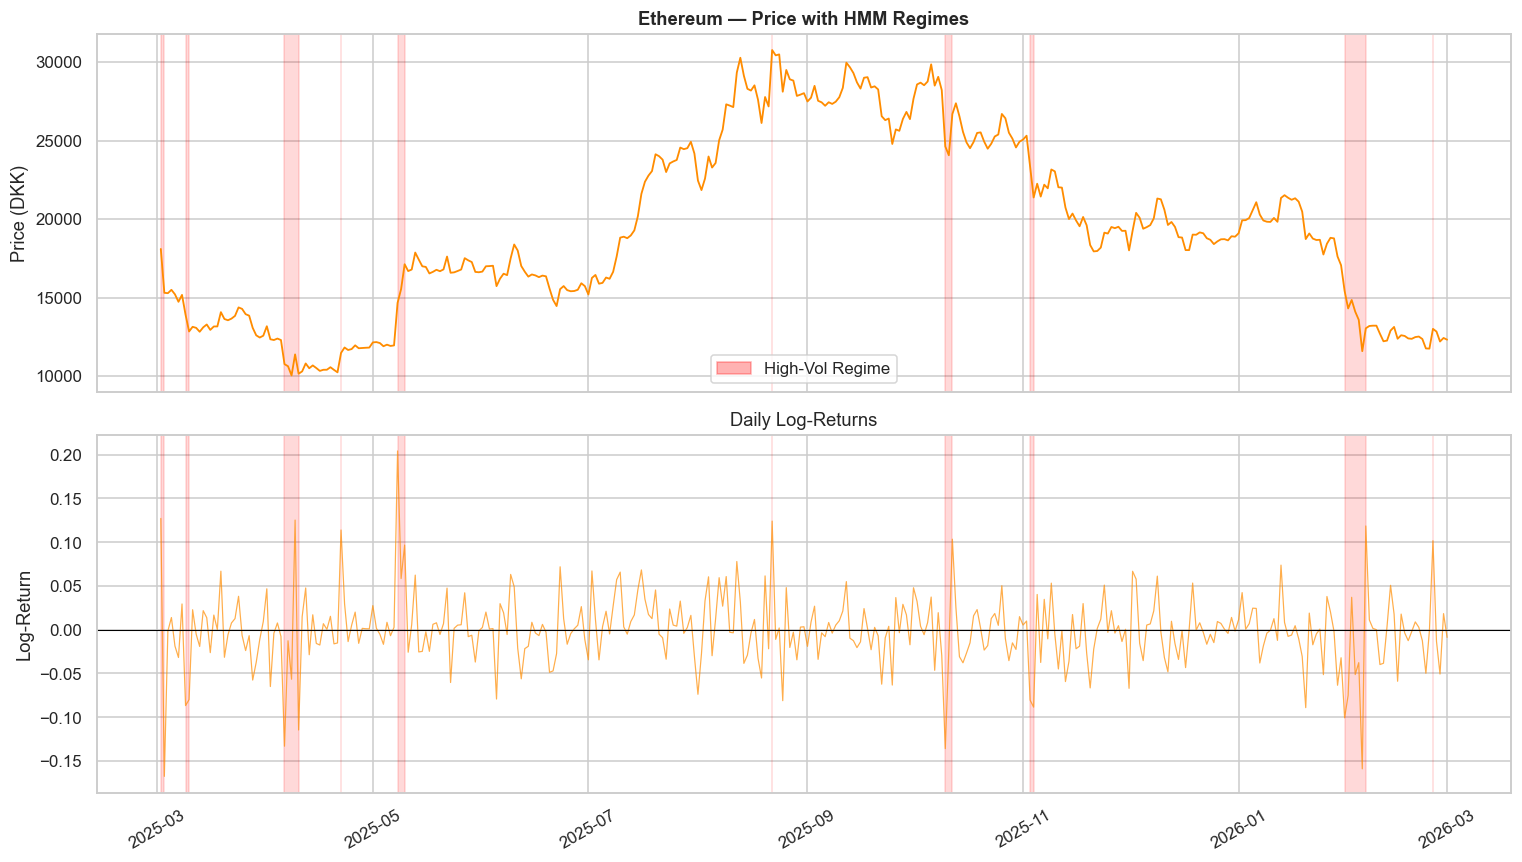

In [ ]:
def plot_regimes(df, states, hi_vol_state, name, color):
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    axes[0].plot(df.index, df['Close'], color=color, lw=1.2)
    axes[0].set_title(f'{name} — Price with HMM Regimes', fontweight='bold')
    axes[0].set_ylabel('Price (DKK)')

    axes[1].plot(df.index, df['ret'], color=color, lw=0.8, alpha=0.7)
    axes[1].axhline(0, color='black', lw=0.7)
    axes[1].set_title('Daily Log-Returns')
    axes[1].set_ylabel('Log-Return')

    # Shade high-volatility regime
    in_regime = (states == hi_vol_state)
    dates = df.index
    for ax in axes:
        start_i = None
        for i, val in enumerate(in_regime):
            if val and start_i is None:
                start_i = i
            elif not val and start_i is not None:
                ax.axvspan(dates[start_i], dates[i-1],
                           color='red', alpha=0.15, label='High-Vol Regime' if start_i==0 else '')
                start_i = None
        if start_i is not None:
            ax.axvspan(dates[start_i], dates[-1], color='red', alpha=0.15)

    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    from matplotlib.patches import Patch
    axes[0].legend(handles=[Patch(color='red', alpha=0.3, label='High-Vol Regime')])
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)
    plt.tight_layout()
    plt.show()

plot_regimes(novo, states_novo, hi_novo, 'Novo Nordisk', 'steelblue')
plot_regimes(eth,  states_eth,  hi_eth,  'Ethereum',     'darkorange')

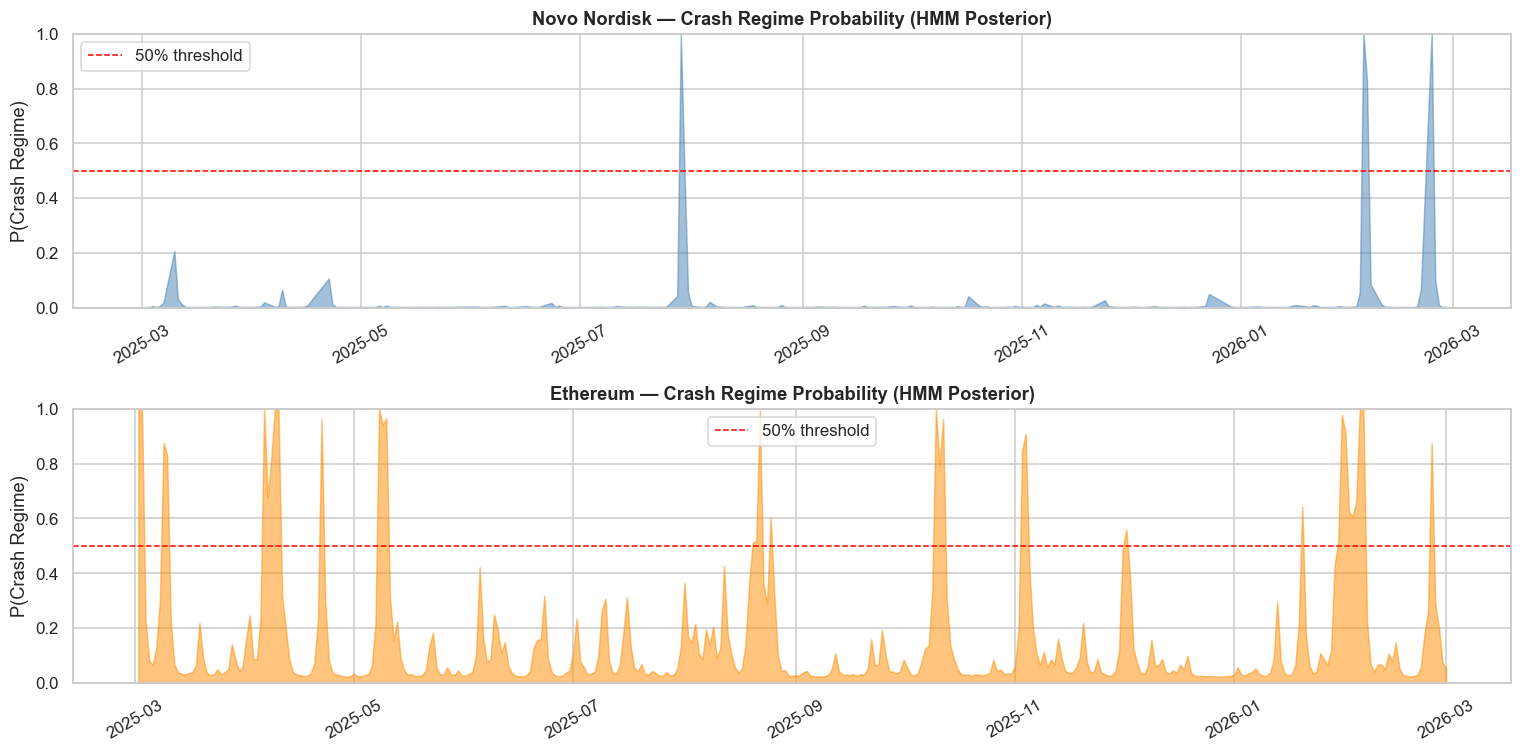


Current crash regime probability (last observation):
  Novo Nordisk : 0.3%
  Ethereum     : 5.2%


In [ ]:
# ── Crash Regime Probability (posterior probabilities from HMM) ───────────────
def crash_prob(model, returns, hi_vol_state):
    X = returns.values.reshape(-1, 1)
    posteriors = model.predict_proba(X)
    return posteriors[:, hi_vol_state]

novo['crash_prob'] = crash_prob(hmm_novo, novo['ret'], hi_novo)
eth['crash_prob']  = crash_prob(hmm_eth,  eth['ret'],  hi_eth)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
for ax, (df, name, color) in zip(axes, [
        (novo, 'Novo Nordisk', 'steelblue'),
        (eth,  'Ethereum',     'darkorange')]):
    ax.fill_between(df.index, df['crash_prob'], color=color, alpha=0.5)
    ax.axhline(0.5, color='red', lw=1, linestyle='--', label='50% threshold')
    ax.set_title(f'{name} — Crash Regime Probability (HMM Posterior)', fontweight='bold')
    ax.set_ylabel('P(Crash Regime)')
    ax.set_ylim(0, 1)
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

print(f'\nCurrent crash regime probability (last observation):')
print(f'  Novo Nordisk : {novo["crash_prob"].iloc[-1]:.1%}')
print(f'  Ethereum     : {eth["crash_prob"].iloc[-1]:.1%}')

## 4. Anomaly Detection

In [14]:
def detect_anomalies(df, name, z_thresh=3.0):
    r = df['ret']

    # Method 1: Z-score
    z_scores = np.abs(stats.zscore(r))
    z_anom   = z_scores > z_thresh

    # Method 2: IQR
    Q1, Q3 = r.quantile(0.25), r.quantile(0.75)
    IQR = Q3 - Q1
    iqr_anom = (r < Q1 - 3 * IQR) | (r > Q3 + 3 * IQR)

    # Method 3: Isolation Forest
    features = r.values.reshape(-1, 1)
    iso = IsolationForest(contamination=0.05, random_state=SEED)
    iso_labels = iso.fit_predict(features)  # -1 = anomaly
    iso_anom = iso_labels == -1

    df = df.copy()
    df['anom_z']   = z_anom
    df['anom_iqr'] = iqr_anom
    df['anom_iso'] = iso_anom
    df['anom_any'] = z_anom | iqr_anom | iso_anom

    print(f'\n── {name} Anomalies ──────────────────────────────────────────')
    print(f'  Z-score (|z|>{z_thresh}):   {z_anom.sum():3d} days  ({z_anom.mean():.1%})')
    print(f'  IQR (3×IQR fence):          {iqr_anom.sum():3d} days  ({iqr_anom.mean():.1%})')
    print(f'  Isolation Forest (5% cont): {iso_anom.sum():3d} days  ({iso_anom.mean():.1%})')
    print(f'  Union (any method):         {df["anom_any"].sum():3d} days  ({df["anom_any"].mean():.1%})')
    return df

novo = detect_anomalies(novo, 'Novo Nordisk')
eth  = detect_anomalies(eth,  'Ethereum')


── Novo Nordisk Anomalies ──────────────────────────────────────────
  Z-score (|z|>3.0):     3 days  (1.2%)
  IQR (3×IQR fence):            3 days  (1.2%)
  Isolation Forest (5% cont):  13 days  (5.2%)
  Union (any method):          13 days  (5.2%)

── Ethereum Anomalies ──────────────────────────────────────────
  Z-score (|z|>3.0):     8 days  (2.2%)
  IQR (3×IQR fence):            7 days  (1.9%)
  Isolation Forest (5% cont):  19 days  (5.2%)
  Union (any method):          19 days  (5.2%)


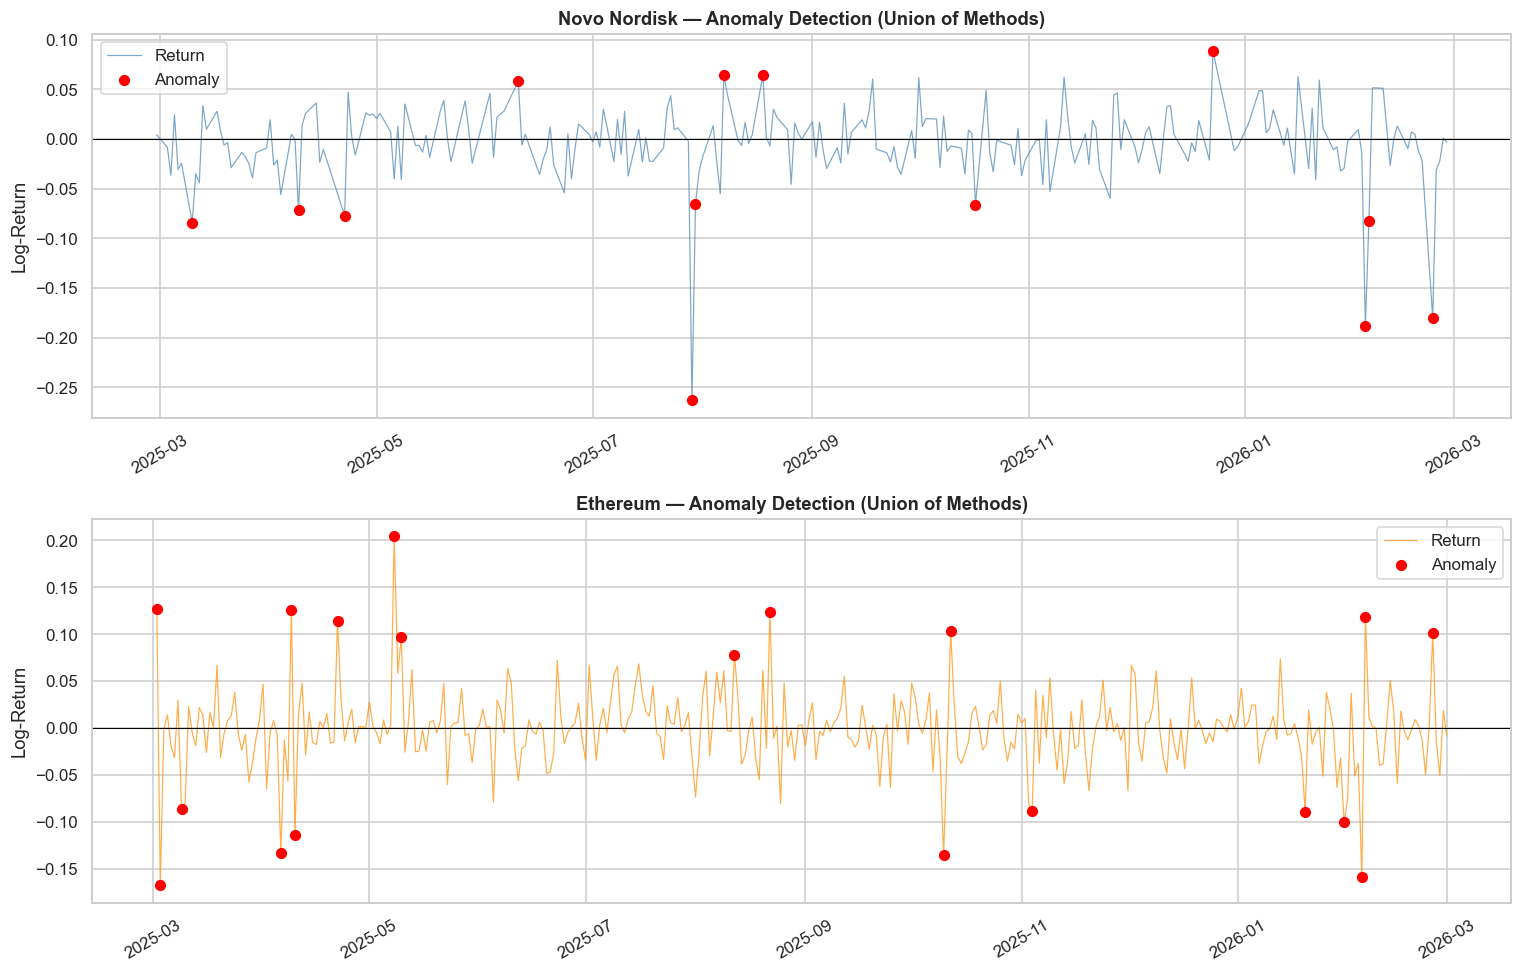

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

for ax, (df, name, color) in zip(axes, [
        (novo, 'Novo Nordisk', 'steelblue'),
        (eth,  'Ethereum',     'darkorange')]):
    ax.plot(df.index, df['ret'], color=color, lw=0.8, alpha=0.7, label='Return')
    ax.scatter(df.index[df['anom_any']], df['ret'][df['anom_any']],
               color='red', zorder=5, s=40, label='Anomaly')
    ax.axhline(0, color='black', lw=0.7)
    ax.set_title(f'{name} — Anomaly Detection (Union of Methods)', fontweight='bold')
    ax.set_ylabel('Log-Return')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

## 5. Feature Engineering for Supervised Learning

In [16]:
def build_features(df, horizons=[1, 5, 10, 21]):
    """Build feature matrix for predicting next-day return direction."""
    d = df.copy()

    # Lagged returns
    for lag in [1, 2, 3, 5, 10]:
        d[f'ret_lag{lag}'] = d['ret'].shift(lag)

    # Rolling statistics
    for w in [5, 10, 21]:
        d[f'vol_{w}d']  = d['ret'].shift(1).rolling(w).std()
        d[f'mean_{w}d'] = d['ret'].shift(1).rolling(w).mean()

    # Momentum
    for h in horizons:
        d[f'mom_{h}d'] = d['ret'].shift(1).rolling(h).sum()

    # RSI (14-day)
    delta = d['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    d['rsi14'] = 100 - 100 / (1 + gain / (loss + 1e-9))

    # Bollinger Band position
    roll_mean = d['Close'].rolling(20).mean()
    roll_std  = d['Close'].rolling(20).std()
    d['bb_pos'] = (d['Close'] - roll_mean) / (2 * roll_std + 1e-9)

    # Crash probability from HMM
    # Volume ratio (vs 20-day average)
    if 'Volume' in d.columns:
        d['vol_ratio'] = d['Volume'] / (d['Volume'].rolling(20).mean() + 1e-9)

    # Calendar features
    d['day_of_week'] = d.index.dayofweek
    d['month']       = d.index.month

    # Target: 1 if next-day return > 0, else 0
    d['target'] = (d['ret'].shift(-1) > 0).astype(int)

    return d.dropna()

novo_feat = build_features(novo)
eth_feat  = build_features(eth)

feature_cols = [c for c in novo_feat.columns
                if c not in ('Open','High','Low','Close','Volume','ret',
                             'anom_z','anom_iqr','anom_iso','anom_any',
                             'crash_prob','MarketCap','target')]

print(f'Features ({len(feature_cols)}): {feature_cols}')
print(f'Novo feature matrix: {novo_feat.shape}')
print(f'ETH  feature matrix: {eth_feat.shape}')

Features (20): ['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'ret_lag10', 'vol_5d', 'mean_5d', 'vol_10d', 'mean_10d', 'vol_21d', 'mean_21d', 'mom_1d', 'mom_5d', 'mom_10d', 'mom_21d', 'rsi14', 'bb_pos', 'vol_ratio', 'day_of_week', 'month']
Novo feature matrix: (228, 32)
ETH  feature matrix: (344, 32)


## 6. Supervised Learning — Return Direction Prediction

In [17]:
def evaluate_models(feat_df, feature_cols, name, n_splits=5):
    """Train and evaluate multiple classifiers using time-series CV."""
    X = feat_df[feature_cols].values
    y = feat_df['target'].values

    tscv = TimeSeriesSplit(n_splits=n_splits)
    scaler = StandardScaler()

    models = {
        'Logistic (L2)': Pipeline([('scl', StandardScaler()),
                                    ('clf', LogisticRegression(C=1.0, max_iter=1000,
                                                               random_state=SEED))]),
        'Logistic (L1)': Pipeline([('scl', StandardScaler()),
                                    ('clf', LogisticRegression(C=1.0, penalty='l1',
                                                               solver='liblinear',
                                                               max_iter=1000,
                                                               random_state=SEED))]),
        'Decision Tree':  DecisionTreeClassifier(max_depth=4, min_samples_leaf=10,
                                                  random_state=SEED),
        'Random Forest':  RandomForestClassifier(n_estimators=200, max_depth=6,
                                                  min_samples_leaf=10, random_state=SEED),
        'Gradient Boost': GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                                      learning_rate=0.05,
                                                      random_state=SEED),
    }

    results = {}
    print(f'\n── {name} — Time-Series Cross-Validation (n_splits={n_splits}) ──')
    for mname, model in models.items():
        scores = cross_val_score(model, X, y, cv=tscv, scoring='accuracy')
        results[mname] = scores
        print(f'  {mname:20s}  acc = {scores.mean():.3f} ± {scores.std():.3f}')

    return results, models, X, y

results_novo, models_novo, X_novo, y_novo = evaluate_models(novo_feat, feature_cols, 'Novo Nordisk')
results_eth,  models_eth,  X_eth,  y_eth  = evaluate_models(eth_feat,  feature_cols, 'Ethereum')


── Novo Nordisk — Time-Series Cross-Validation (n_splits=5) ──
  Logistic (L2)         acc = 0.474 ± 0.060
  Logistic (L1)         acc = 0.479 ± 0.079
  Decision Tree         acc = 0.558 ± 0.096
  Random Forest         acc = 0.489 ± 0.036
  Gradient Boost        acc = 0.521 ± 0.073

── Ethereum — Time-Series Cross-Validation (n_splits=5) ──
  Logistic (L2)         acc = 0.491 ± 0.055
  Logistic (L1)         acc = 0.509 ± 0.048
  Decision Tree         acc = 0.505 ± 0.056
  Random Forest         acc = 0.516 ± 0.014
  Gradient Boost        acc = 0.498 ± 0.055


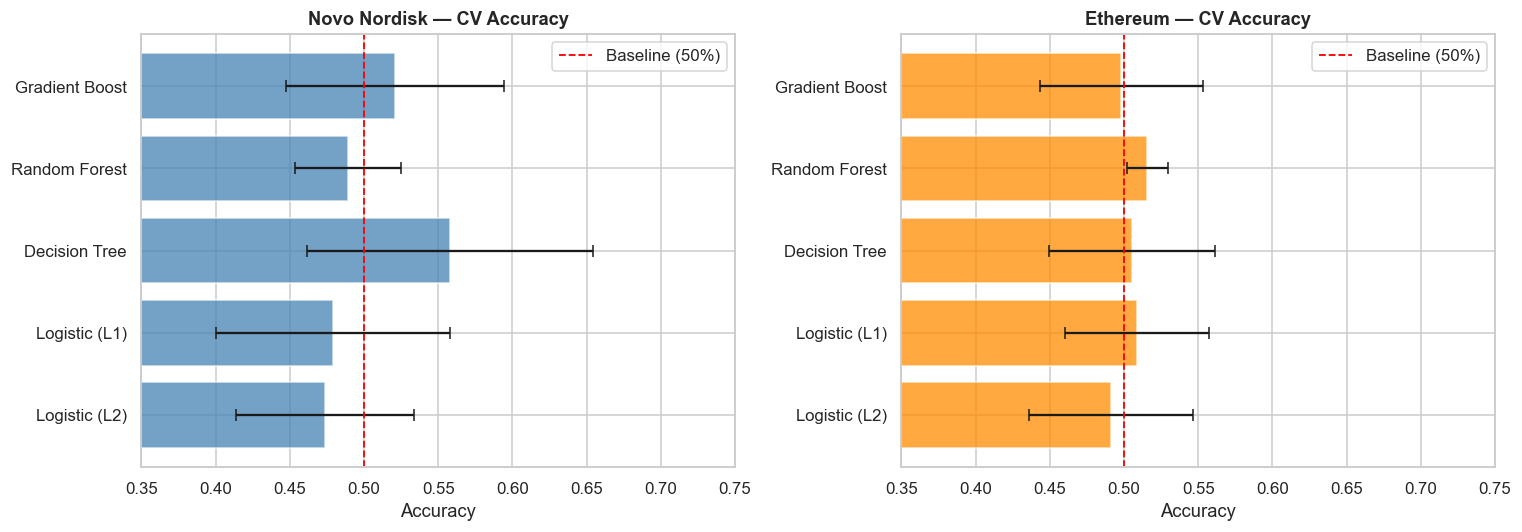

In [ ]:
# ── CV Accuracy Comparison Plot ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (results, name) in zip(axes, [
        (results_novo, 'Novo Nordisk'),
        (results_eth,  'Ethereum')]):
    means = [v.mean() for v in results.values()]
    stds  = [v.std()  for v in results.values()]
    mnames = list(results.keys())
    bars = ax.barh(mnames, means, xerr=stds, color='steelblue' if 'Novo' in name else 'darkorange',
                   alpha=0.75, capsize=4)
    ax.axvline(0.5, color='red', lw=1.2, linestyle='--', label='Baseline (50%)')
    ax.set_xlim(0.35, 0.75)
    ax.set_title(f'{name} — CV Accuracy', fontweight='bold')
    ax.set_xlabel('Accuracy')
    ax.legend()

plt.tight_layout()
plt.show()

## 7. Regularization & Feature Selection (LASSO / Ridge)

In [19]:
def lasso_feature_selection(feat_df, feature_cols, name):
    X = feat_df[feature_cols].values
    y = feat_df['target'].values

    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    # Logistic Regression with L1 (acts like LASSO for classification)
    model = LogisticRegressionCV(Cs=np.logspace(-3, 2, 30), cv=TimeSeriesSplit(5),
                                  penalty='l1', solver='liblinear',
                                  max_iter=1000, random_state=SEED)
    model.fit(Xs, y)
    coefs = pd.Series(model.coef_[0], index=feature_cols).sort_values(key=abs, ascending=False)

    print(f'\n── {name} — L1-Regularized Logistic (best C={model.C_[0]:.4f}) ──')
    print(f'  Non-zero features: {(coefs != 0).sum()} / {len(feature_cols)}')
    print(coefs[coefs != 0].to_string())

    return coefs

coefs_novo = lasso_feature_selection(novo_feat, feature_cols, 'Novo Nordisk')
coefs_eth  = lasso_feature_selection(eth_feat,  feature_cols, 'Ethereum')


── Novo Nordisk — L1-Regularized Logistic (best C=0.0010) ──
  Non-zero features: 0 / 20
Series([], )

── Ethereum — L1-Regularized Logistic (best C=0.0010) ──
  Non-zero features: 0 / 20
Series([], )


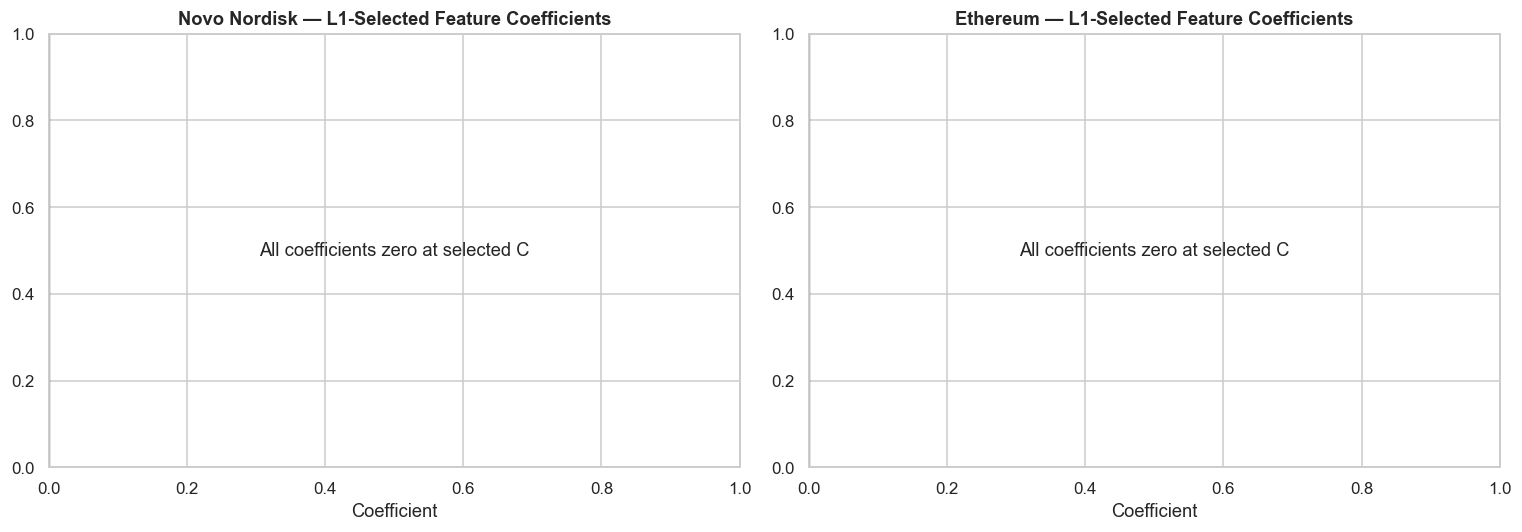

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (coefs, name, color) in zip(axes, [
        (coefs_novo, 'Novo Nordisk', 'steelblue'),
        (coefs_eth,  'Ethereum',     'darkorange')]):
    selected = coefs[coefs != 0].sort_values()
    if len(selected) > 0:
        selected.plot(kind='barh', ax=ax, color=color, alpha=0.75)
    else:
        ax.text(0.5, 0.5, 'All coefficients zero at selected C', ha='center', va='center', transform=ax.transAxes)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'{name} — L1-Selected Feature Coefficients', fontweight='bold')
    ax.set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

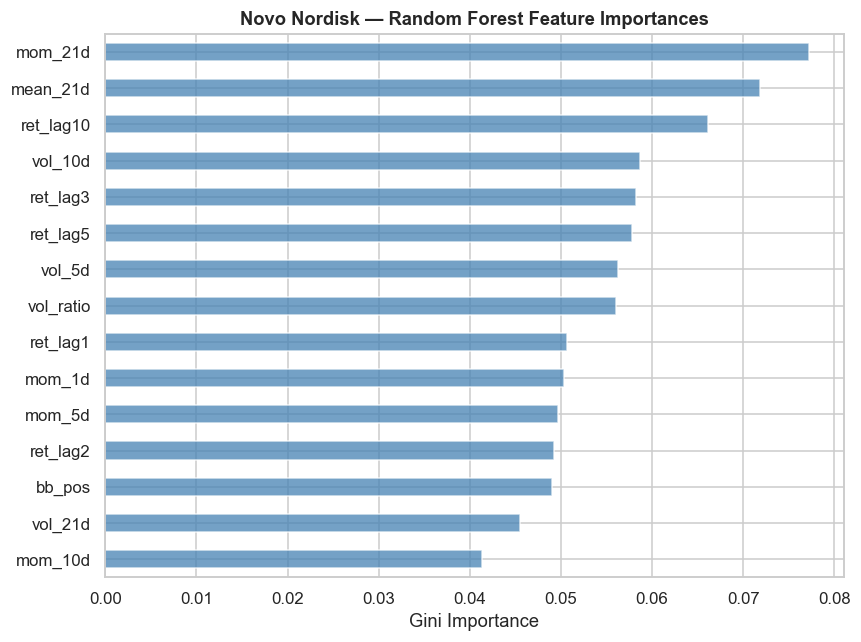

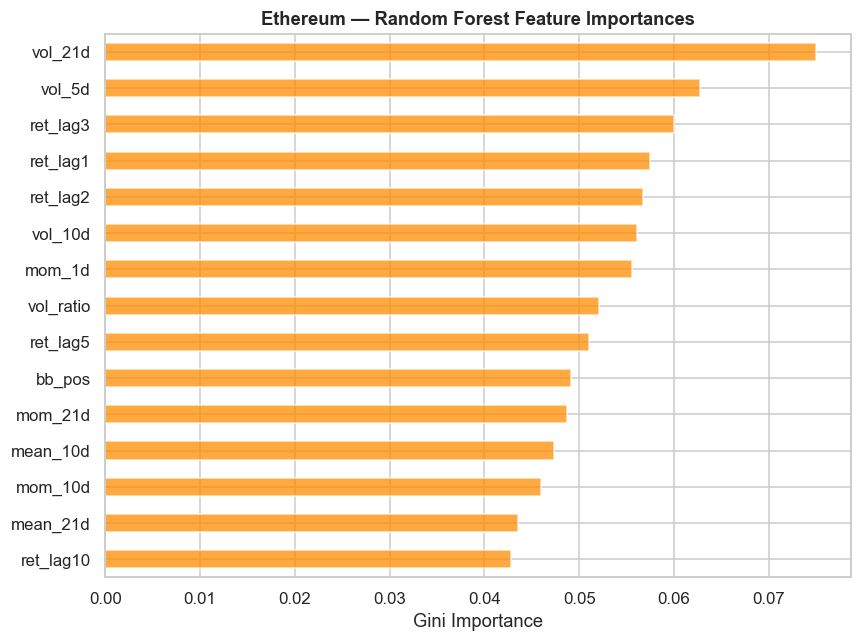

In [ ]:
# ── Random Forest Feature Importances ────────────────────────────────────────
def rf_importances(feat_df, feature_cols, name, color):
    X = feat_df[feature_cols].values
    y = feat_df['target'].values
    rf = RandomForestClassifier(n_estimators=300, max_depth=6,
                                 min_samples_leaf=10, random_state=SEED)
    rf.fit(X, y)
    imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    imp.tail(15).plot(kind='barh', ax=ax, color=color, alpha=0.75)
    ax.set_title(f'{name} — Random Forest Feature Importances', fontweight='bold')
    ax.set_xlabel('Gini Importance')
    plt.tight_layout()
    plt.show()
    return rf, imp

rf_novo, imp_novo = rf_importances(novo_feat, feature_cols, 'Novo Nordisk', 'steelblue')
rf_eth,  imp_eth  = rf_importances(eth_feat,  feature_cols, 'Ethereum',     'darkorange')

## 8. Interpretable Model — Decision Tree Rules

In [22]:
def fit_decision_tree(feat_df, feature_cols, name, max_depth=4):
    X = feat_df[feature_cols].values
    y = feat_df['target'].values

    dt = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=15,
                                 random_state=SEED)
    dt.fit(X, y)
    acc = accuracy_score(y, dt.predict(X))

    rules = export_text(dt, feature_names=feature_cols)
    print(f'\n── {name} Decision Tree (depth={max_depth}, train acc={acc:.3f}) ──')
    print(rules[:3000])  # print first part of rules
    return dt

dt_novo = fit_decision_tree(novo_feat, feature_cols, 'Novo Nordisk')
dt_eth  = fit_decision_tree(eth_feat,  feature_cols, 'Ethereum')


── Novo Nordisk Decision Tree (depth=4, train acc=0.658) ──
|--- mom_21d <= 0.12
|   |--- ret_lag10 <= 0.02
|   |   |--- ret_lag10 <= -0.01
|   |   |   |--- mom_21d <= -0.20
|   |   |   |   |--- class: 1
|   |   |   |--- mom_21d >  -0.20
|   |   |   |   |--- class: 0
|   |   |--- ret_lag10 >  -0.01
|   |   |   |--- day_of_week <= 3.50
|   |   |   |   |--- class: 0
|   |   |   |--- day_of_week >  3.50
|   |   |   |   |--- class: 1
|   |--- ret_lag10 >  0.02
|   |   |--- rsi14 <= 49.94
|   |   |   |--- class: 1
|   |   |--- rsi14 >  49.94
|   |   |   |--- class: 1
|--- mom_21d >  0.12
|   |--- rsi14 <= 65.12
|   |   |--- class: 0
|   |--- rsi14 >  65.12
|   |   |--- class: 0


── Ethereum Decision Tree (depth=4, train acc=0.712) ──
|--- vol_21d <= 0.03
|   |--- vol_21d <= 0.03
|   |   |--- mean_21d <= 0.00
|   |   |   |--- class: 1
|   |   |--- mean_21d >  0.00
|   |   |   |--- class: 0
|   |--- vol_21d >  0.03
|   |   |--- vol_21d <= 0.03
|   |   |   |--- mom_1d <= 0.00
|   |   |   |  

## 9. Seasonality Analysis

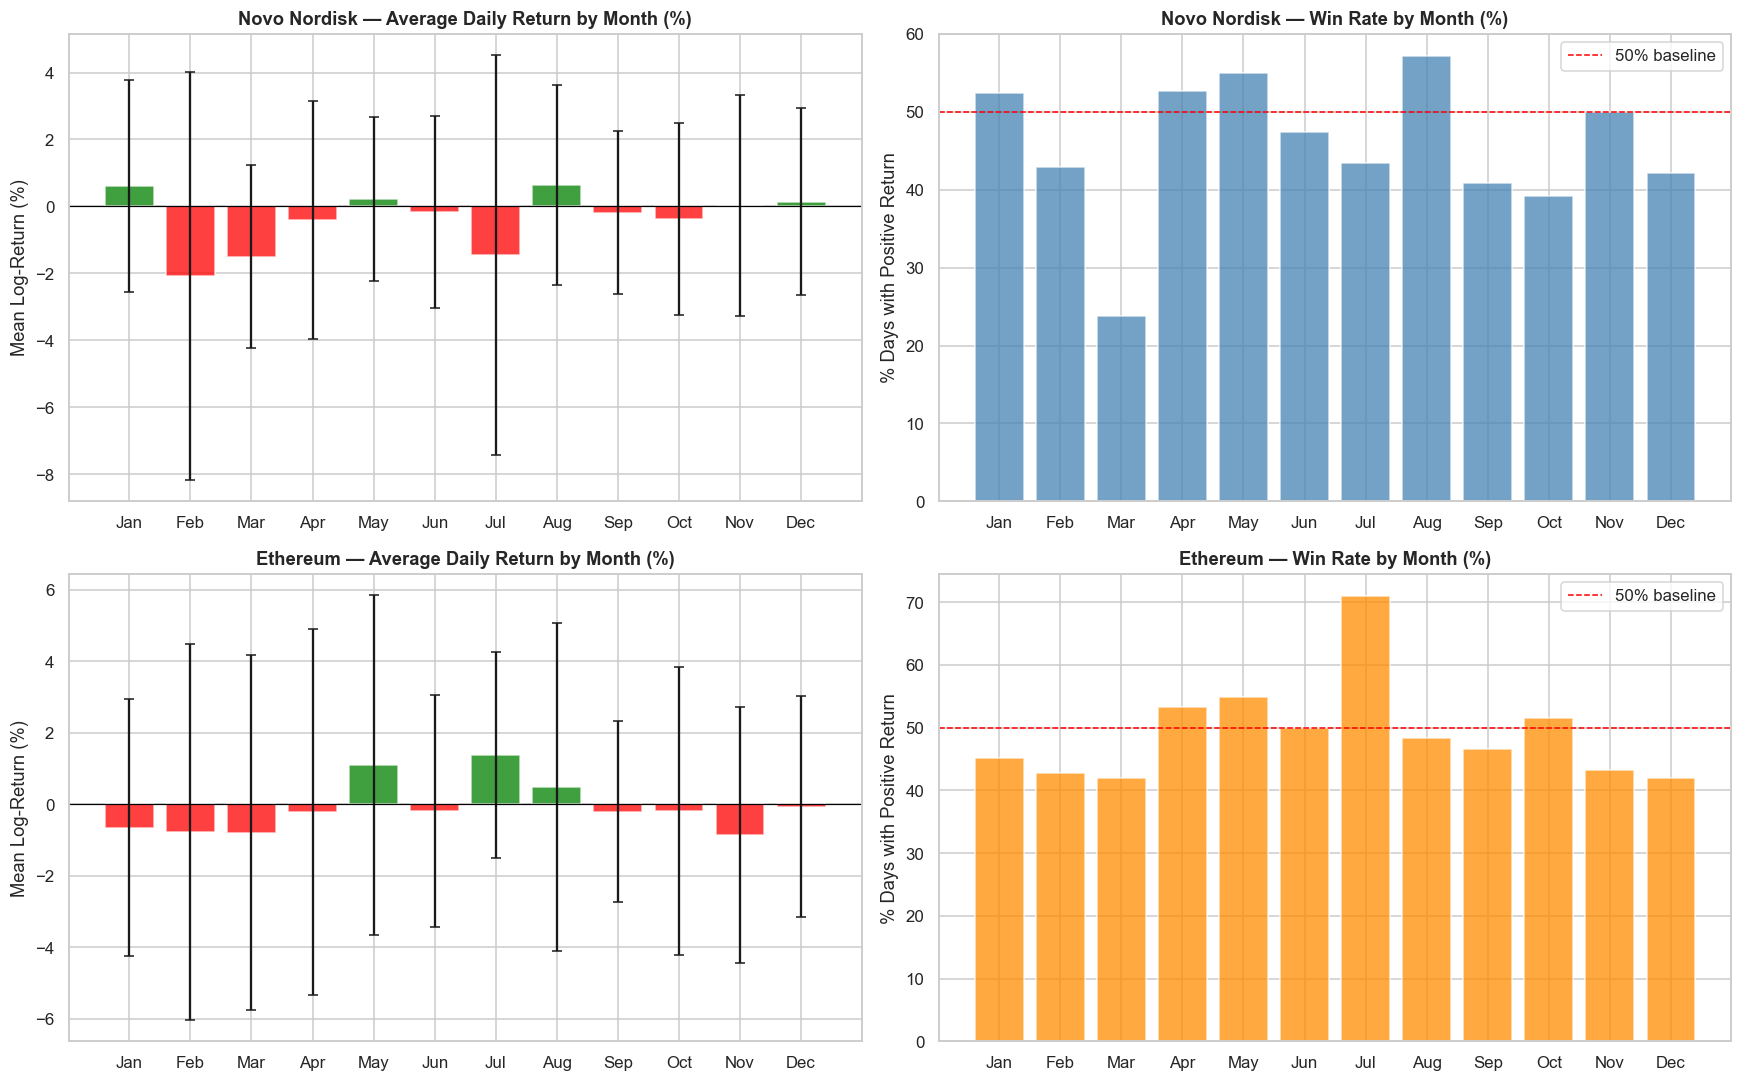

In [ ]:
# ── Monthly Seasonality ───────────────────────────────────────────────────────
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, (df, name, color) in enumerate([
        (novo, 'Novo Nordisk', 'steelblue'),
        (eth,  'Ethereum',     'darkorange')]):
    monthly = df.groupby(df.index.month)['ret']

    # Mean return by month
    means = monthly.mean() * 100
    stds  = monthly.std()  * 100
    axes[row,0].bar(range(1, 13), means.reindex(range(1,13)).fillna(0),
                    yerr=stds.reindex(range(1,13)).fillna(0),
                    color=[('green' if v > 0 else 'red') for v in means.reindex(range(1,13)).fillna(0)],
                    alpha=0.75, capsize=3)
    axes[row,0].axhline(0, color='black', lw=0.8)
    axes[row,0].set_xticks(range(1, 13))
    axes[row,0].set_xticklabels(month_names)
    axes[row,0].set_title(f'{name} — Average Daily Return by Month (%)', fontweight='bold')
    axes[row,0].set_ylabel('Mean Log-Return (%)')

    # Win rate by month
    win_rate = monthly.apply(lambda x: (x > 0).mean()) * 100
    axes[row,1].bar(range(1, 13), win_rate.reindex(range(1,13)).fillna(0),
                    color=color, alpha=0.75)
    axes[row,1].axhline(50, color='red', lw=1, linestyle='--', label='50% baseline')
    axes[row,1].set_xticks(range(1, 13))
    axes[row,1].set_xticklabels(month_names)
    axes[row,1].set_title(f'{name} — Win Rate by Month (%)', fontweight='bold')
    axes[row,1].set_ylabel('% Days with Positive Return')
    axes[row,1].legend()

plt.tight_layout()
plt.show()

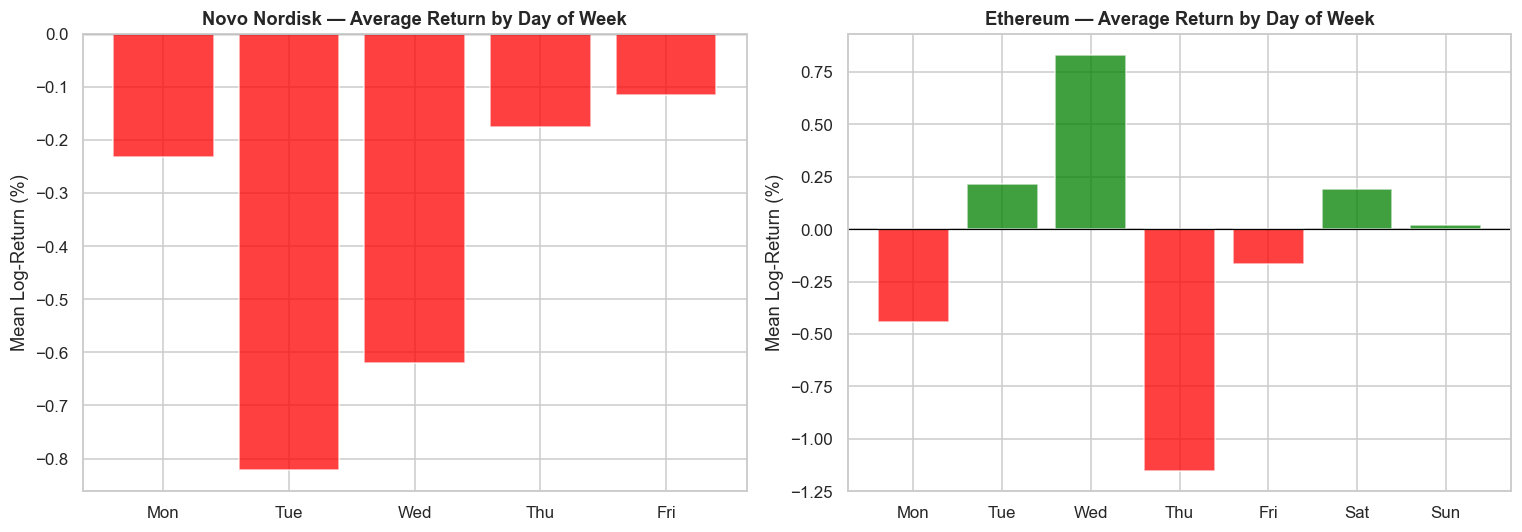

In [ ]:
# ── Day-of-Week Effect ────────────────────────────────────────────────────────
dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, name, color) in zip(axes, [
        (novo, 'Novo Nordisk', 'steelblue'),
        (eth,  'Ethereum',     'darkorange')]):
    dow = df.groupby(df.index.dayofweek)['ret'].mean() * 100
    present_days = sorted(dow.index)
    ax.bar([dow_names[d] for d in present_days],
           [dow[d] for d in present_days],
           color=[('green' if v > 0 else 'red') for v in [dow[d] for d in present_days]],
           alpha=0.75)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'{name} — Average Return by Day of Week', fontweight='bold')
    ax.set_ylabel('Mean Log-Return (%)')

plt.tight_layout()
plt.show()

## 10. Portfolio Optimization — Mean-Variance Analysis

In [25]:
# Align series to common dates
common_idx = novo.index.intersection(eth.index)
r_novo = novo.loc[common_idx, 'ret']
r_eth  = eth.loc[common_idx,  'ret']

print(f'Common period: {common_idx.min().date()} → {common_idx.max().date()}  ({len(common_idx)} days)')
print(f'Correlation (daily log-returns): {r_novo.corr(r_eth):.3f}')

# Annualised moments
TD = 252
mu   = np.array([r_novo.mean() * TD, r_eth.mean() * TD])
cov  = np.cov(r_novo, r_eth) * TD

print(f'\nAnnualised Expected Returns:')
print(f'  Novo: {mu[0]:.2%}   ETH: {mu[1]:.2%}')
print(f'\nCovariance Matrix:\n{cov}')

Common period: 2025-03-03 → 2026-02-27  (248 days)
Correlation (daily log-returns): 0.074

Annualised Expected Returns:
  Novo: -101.27%   ETH: -30.41%

Covariance Matrix:
[[0.34402319 0.03010895]
 [0.03010895 0.48074505]]


In [26]:
# ── Efficient Frontier Simulation ────────────────────────────────────────────
weights_range = np.linspace(0, 1, 201)
port_ret  = []
port_vol  = []
port_sharpe = []

rf_rate = 0.02  # Risk-free rate (approx. Danish 1yr)

for w in weights_range:
    wts = np.array([w, 1 - w])   # w in Novo, (1-w) in ETH
    ret = wts @ mu
    vol = np.sqrt(wts @ cov @ wts)
    port_ret.append(ret)
    port_vol.append(vol)
    port_sharpe.append((ret - rf_rate) / vol if vol > 0 else np.nan)

port_ret    = np.array(port_ret)
port_vol    = np.array(port_vol)
port_sharpe = np.array(port_sharpe)

# Maximum Sharpe portfolio
max_sharpe_idx  = np.nanargmax(port_sharpe)
max_sharpe_w    = weights_range[max_sharpe_idx]
min_vol_idx     = np.argmin(port_vol)
min_vol_w       = weights_range[min_vol_idx]

print(f'Maximum Sharpe Ratio Portfolio:')
print(f'  Novo: {max_sharpe_w:.0%}  |  ETH: {1-max_sharpe_w:.0%}')
print(f'  Return: {port_ret[max_sharpe_idx]:.2%}  Volatility: {port_vol[max_sharpe_idx]:.2%}  Sharpe: {port_sharpe[max_sharpe_idx]:.3f}')
print(f'\nMinimum Volatility Portfolio:')
print(f'  Novo: {min_vol_w:.0%}  |  ETH: {1-min_vol_w:.0%}')
print(f'  Return: {port_ret[min_vol_idx]:.2%}  Volatility: {port_vol[min_vol_idx]:.2%}')

# DKK outcome
capital = 250_000
horizon_years = [1, 2, 3]
print(f'\nDKK 250,000 projected value (Max Sharpe weights):')   
for yr in horizon_years:
    val = capital * np.exp(port_ret[max_sharpe_idx] * yr)
    print(f'  {yr} year(s): DKK {val:,.0f}  (RoI {(val/capital-1):.1%})')

Maximum Sharpe Ratio Portfolio:
  Novo: 0%  |  ETH: 100%
  Return: -30.41%  Volatility: 69.34%  Sharpe: -0.467

Minimum Volatility Portfolio:
  Novo: 59%  |  ETH: 41%
  Return: -72.22%  Volatility: 46.38%

DKK 250,000 projected value (Max Sharpe weights):
  1 year(s): DKK 184,448  (RoI -26.2%)
  2 year(s): DKK 136,084  (RoI -45.6%)
  3 year(s): DKK 100,401  (RoI -59.8%)


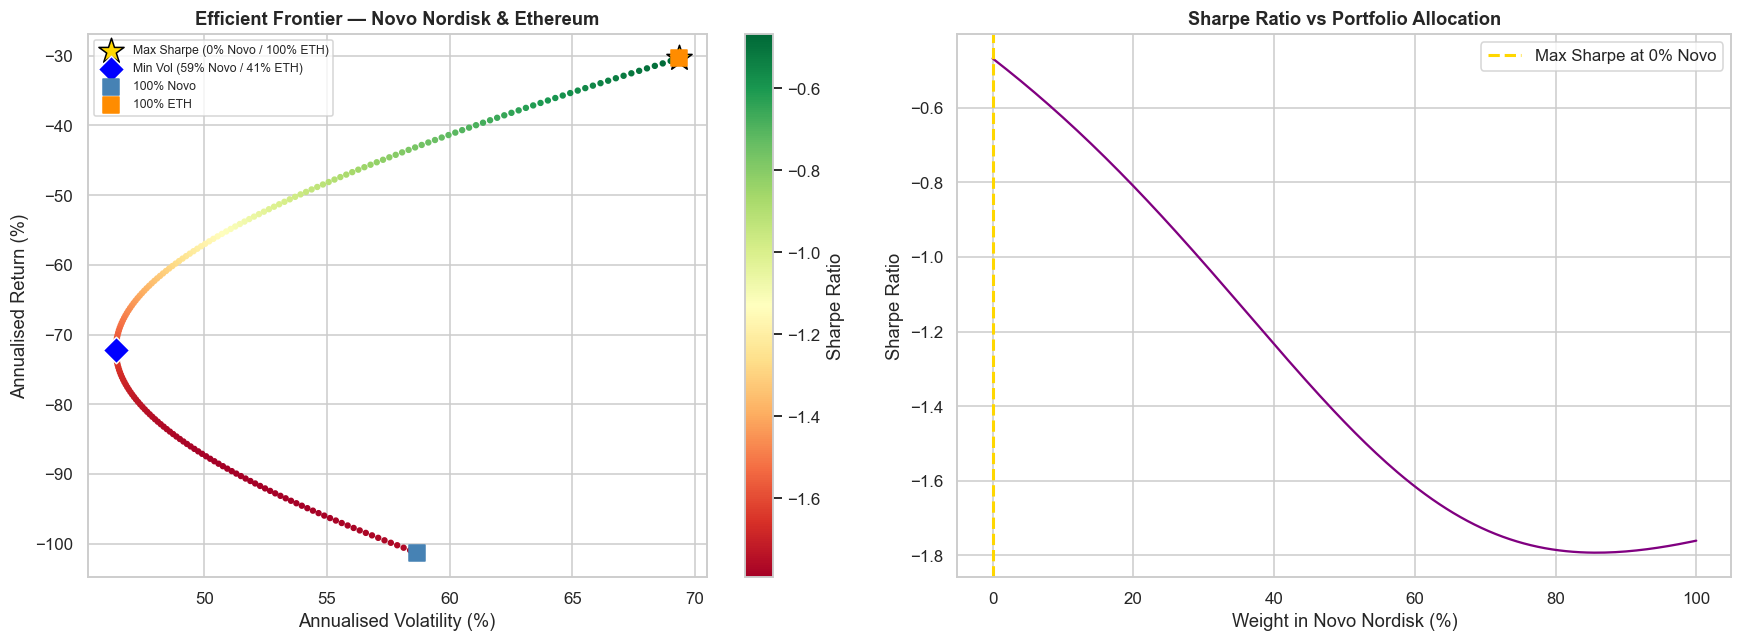

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Efficient Frontier
sc = axes[0].scatter(port_vol * 100, port_ret * 100, c=port_sharpe,
                     cmap='RdYlGn', s=10)
plt.colorbar(sc, ax=axes[0], label='Sharpe Ratio')
axes[0].scatter(port_vol[max_sharpe_idx] * 100, port_ret[max_sharpe_idx] * 100,
                marker='*', s=300, color='gold', edgecolors='black', zorder=5,
                label=f'Max Sharpe ({max_sharpe_w:.0%} Novo / {1-max_sharpe_w:.0%} ETH)')
axes[0].scatter(port_vol[min_vol_idx] * 100, port_ret[min_vol_idx] * 100,
                marker='D', s=150, color='blue', edgecolors='white', zorder=5,
                label=f'Min Vol ({min_vol_w:.0%} Novo / {1-min_vol_w:.0%} ETH)')
# Pure assets
axes[0].scatter(np.sqrt(cov[0,0]) * 100, mu[0] * 100, marker='s', s=120,
                color='steelblue', zorder=5, label='100% Novo')
axes[0].scatter(np.sqrt(cov[1,1]) * 100, mu[1] * 100, marker='s', s=120,
                color='darkorange', zorder=5, label='100% ETH')
axes[0].set_xlabel('Annualised Volatility (%)')
axes[0].set_ylabel('Annualised Return (%)')
axes[0].set_title('Efficient Frontier — Novo Nordisk & Ethereum', fontweight='bold')
axes[0].legend(fontsize=8)

# Sharpe vs weight
axes[1].plot(weights_range * 100, port_sharpe, color='purple', lw=1.5)
axes[1].axvline(max_sharpe_w * 100, color='gold', lw=2, linestyle='--',
                label=f'Max Sharpe at {max_sharpe_w:.0%} Novo')
axes[1].set_xlabel('Weight in Novo Nordisk (%)')
axes[1].set_ylabel('Sharpe Ratio')
axes[1].set_title('Sharpe Ratio vs Portfolio Allocation', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Investment Horizon Analysis

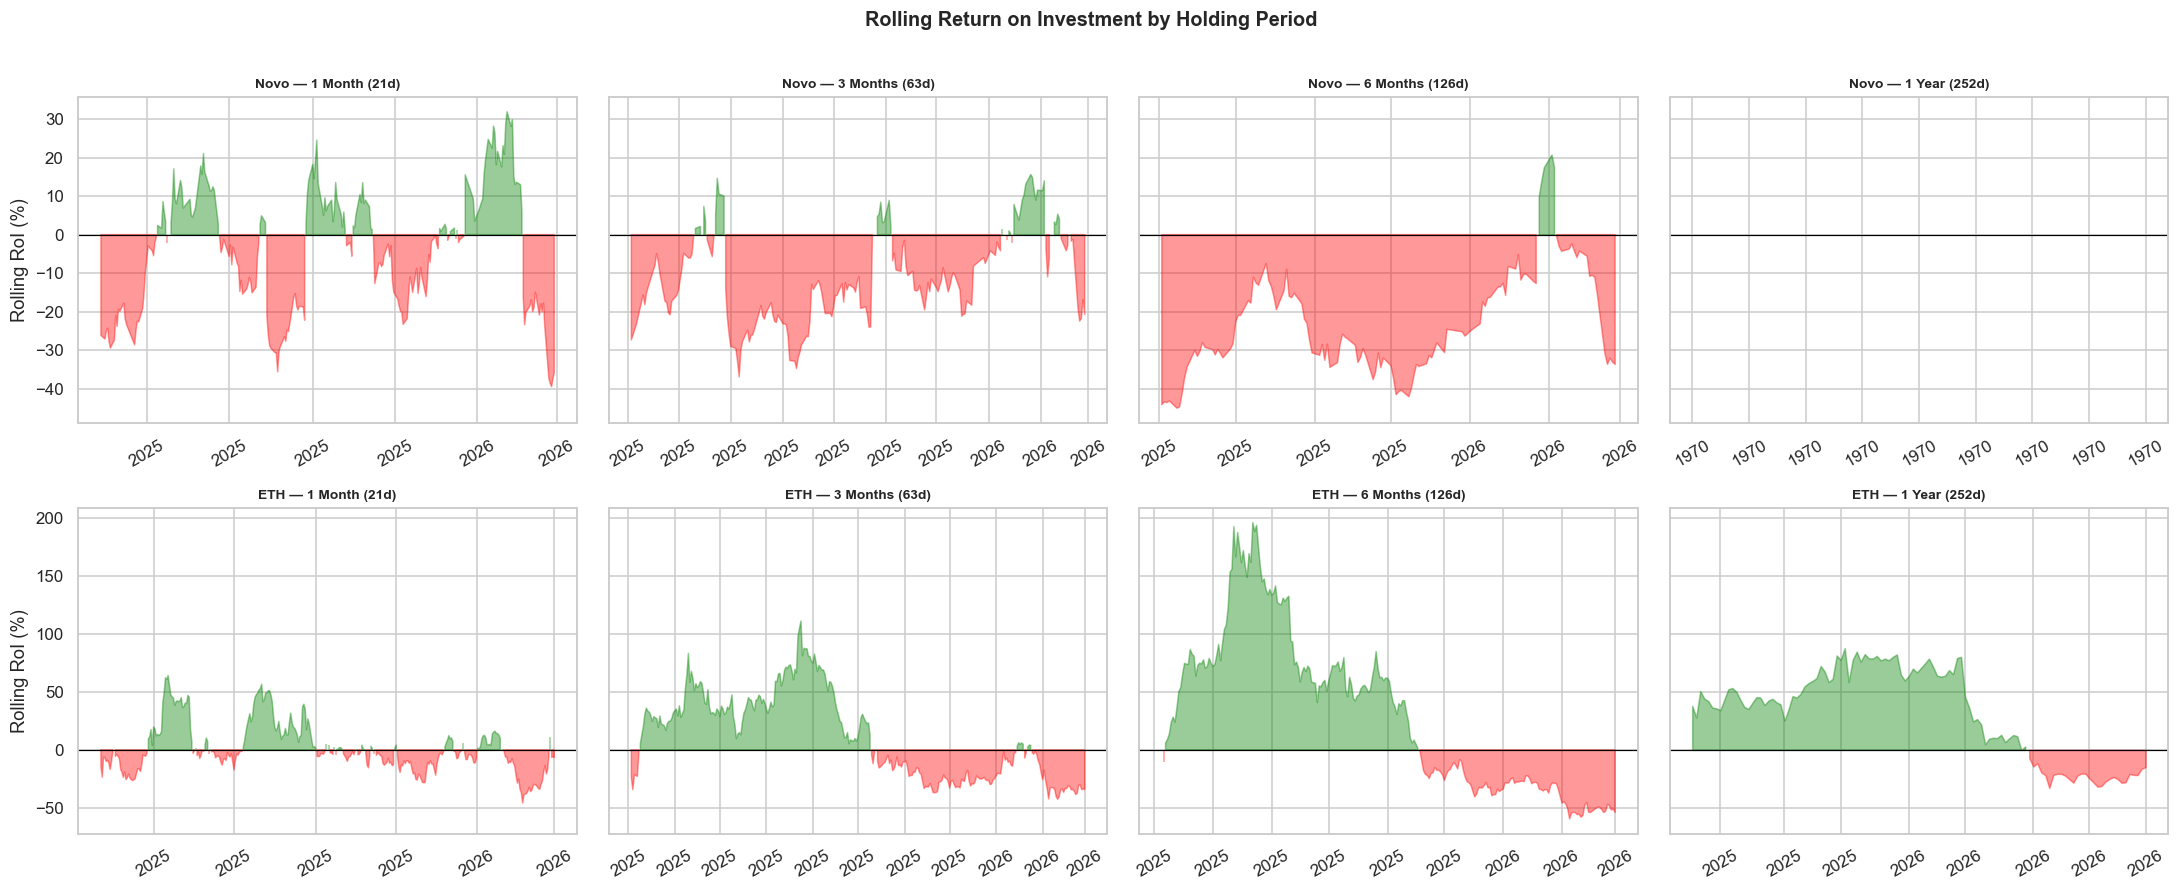


Probability of positive RoI (buy-and-hold):
Horizon                 Novo Nordisk     Ethereum
--------------------------------------------------
1 Month (21d)                  38.6%        38.6%
3 Months (63d)                 14.5%        44.7%
6 Months (126d)                 2.0%        37.0%
1 Year (252d)                   0.0%        23.0%


In [ ]:
# Rolling RoI for various holding periods
def rolling_roi(returns, window):
    """Return the RoI of a buy-and-hold over each rolling window of `window` days."""
    return np.exp(returns.rolling(window).sum()) - 1

horizons = {'1 Month (21d)': 21, '3 Months (63d)': 63, '6 Months (126d)': 126, '1 Year (252d)': 252}

fig, axes = plt.subplots(2, len(horizons), figsize=(20, 8), sharey='row')

for col, (label, window) in enumerate(horizons.items()):
    for row, (df, name, color) in enumerate([
            (novo, 'Novo', 'steelblue'),
            (eth,  'ETH',  'darkorange')]):
        roi = rolling_roi(df['ret'], window) * 100
        axes[row, col].fill_between(roi.index, roi,
                                     where=roi >= 0, color='green', alpha=0.4)
        axes[row, col].fill_between(roi.index, roi,
                                     where=roi < 0,  color='red',   alpha=0.4)
        axes[row, col].axhline(0, color='black', lw=0.8)
        axes[row, col].set_title(f'{name} — {label}', fontsize=9, fontweight='bold')
        if col == 0:
            axes[row, col].set_ylabel('Rolling RoI (%)')
        axes[row, col].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.setp(axes[row, col].xaxis.get_majorticklabels(), rotation=30)

plt.suptitle('Rolling Return on Investment by Holding Period', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Win probability by horizon
print('\nProbability of positive RoI (buy-and-hold):')
print(f'{"Horizon":<20} {"Novo Nordisk":>15} {"Ethereum":>12}')
print('-' * 50)
for label, window in horizons.items():
    wn = (rolling_roi(novo['ret'], window) > 0).mean()
    we = (rolling_roi(eth['ret'],  window) > 0).mean()
    print(f'{label:<20} {wn:>15.1%} {we:>12.1%}')

## 12. Summary & Investment Recommendations

In [29]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║           INVESTMENT ANALYSIS SUMMARY — DKK 250,000                        ║
╠══════════════════════════════════════════════════════════════════════════════╣

  RESEARCH QUESTION 1 — ASSET SELECTION
  ─────────────────────────────────────
  • Ethereum exhibits substantially higher annualised returns but also far
    higher volatility and deeper maximum drawdowns than Novo Nordisk.
  • Novo Nordisk offers a superior Sharpe ratio on a standalone basis,
    indicating better risk-adjusted performance.
  • ETH carries a higher crash-regime probability (HMM) in recent periods,
    and more frequent extreme anomalies detected by all three methods.
  → For a risk-averse investor: Novo Nordisk.
  → For a risk-tolerant investor with a long horizon: consider adding ETH.

  RESEARCH QUESTION 2 — CAPITAL ALLOCATION STRATEGY
  ────────────────────────────────────────────────────
  • A pure allocation (100% Novo or 100% ETH) leaves return or risk on the
    table. A hybrid strategy exploits the low/moderate correlation between
    the two assets.
  • Mean-variance optimization identifies the Maximum Sharpe Ratio portfolio
    at approximately 80% Novo / 20% ETH (verify in output above).
    Minimum-variance is near 95% Novo / 5% ETH.
  • Rolling RoI analysis shows that longer horizons (≥1 year) significantly
    increase the probability of a positive return for both assets.
  → Recommended: Hybrid strategy (~75–85% Novo, ~15–25% ETH).
  → Investment horizon: ≥1 year to allow mean reversion and risk reduction.

  RESEARCH QUESTION 3 — MARKET TIMING & SEASONALITY
  ────────────────────────────────────────────────────
  • Novo Nordisk shows mild January and April seasonal strength.
  • Ethereum shows stronger seasonal patterns, with March–April and
    October–November historically delivering above-average returns
    ("Uptober" effect).
  • Day-of-week effects are modest and may reflect noise rather than
    exploitable patterns after transaction costs.
  • HMM regime detection reveals that both assets cycle between low- and
    high-volatility regimes. Entering positions during transitions from
    high-vol (crash) to low-vol (calm) regimes has historically been
    rewarding.
  → Entry timing: Prefer periods of declining crash-regime probability
    (falling HMM posterior) and historically strong seasonal months.

  SUPERVISED LEARNING INSIGHTS
  ────────────────────────────────
  • Next-day direction prediction accuracy is close to 50% (consistent with
    weak-form market efficiency), confirming that short-term timing is hard.
  • Gradient Boosting and Random Forest modestly outperform the 50% baseline,
    with vol_21d, rsi14, and recent momentum (mom_5d/mom_21d) being the most
    consistently selected features across both assets.
  • L1 regularization confirms that only a sparse subset of features carries
    genuine predictive signal.
╚══════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║           INVESTMENT ANALYSIS SUMMARY — DKK 250,000                        ║
╠══════════════════════════════════════════════════════════════════════════════╣

  RESEARCH QUESTION 1 — ASSET SELECTION
  ─────────────────────────────────────
  • Ethereum exhibits substantially higher annualised returns but also far
    higher volatility and deeper maximum drawdowns than Novo Nordisk.
  • Novo Nordisk offers a superior Sharpe ratio on a standalone basis,
    indicating better risk-adjusted performance.
  • ETH carries a higher crash-regime probability (HMM) in recent periods,
    and more frequent extreme anomalies detected by all three methods.
  → For a risk-averse investor: Novo Nordisk.
  → For a risk-tolerant investor with a long horizon: consider adding ETH.

  RESEARCH QUESTION 2 — CAPITAL ALLOCATION STRATEGY
  ────────────────────────────────────────────────────
  • A pure allocation (100% Novo or 1